In [ ]:
import sys, os

import numpy as np
import torch
from PIL import Image

sys.path.append("..")
from rich import print

from dataset.highlight import HighlightDataset
from dataset.mono3d_dataset import SCARED
from dataset.highlight import draw_rect
from geometry import euler2mat as e2m
from dataset.rgbp import SYNTHETIC_Dataset
from utilities.visualization import panelize, rgb


%load_ext autoreload
%autoreload 2

In [75]:
dataset = SYNTHETIC_Dataset(
    root_dir="$DATASET_DIR/SyntheticMitsuba/",
    include="scene_0",
    polarization_format="separate_files_stokes",
    pol_ext=".npy",
    target_size=(720//2, 1280//2),
    resize_mode="resize",
    # highlight_enable=True,
    # highlight_brightness_threshold=0.93,
    # highlight_return_mask=True,
    # highlight_rect_size=(640,640),
    # highlight_return_rect=True,
    # highlight_return_rect_as_rgb=True,
)
len(dataset)
# sample contains: rgb, specular, diffuse, intrinsics, and highlight_* keys

1

In [76]:
dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=1
)  # , sampler=dataset.sampler)
iloader = iter(dataloader)
sample = next(iloader)
# sample = {k: v for k, v in sample_full.items() if k in ["rgb", "rect_crop", "rect_mask", "rect_coords", "highlight_masks", "highlight_coverage"]}
print({k: v.shape if isinstance(v, torch.Tensor) else v for k, v in sample.items()})


torch.Size([720, 1280])


{
    'I0': torch.Size([1, 3, 360, 640]),
    'I45': torch.Size([1, 3, 360, 640]),
    'I90': torch.Size([1, 3, 360, 640]),
    'I135': torch.Size([1, 3, 360, 640]),
    'S0': torch.Size([1, 1, 360, 640]),
    'S1': torch.Size([1, 1, 360, 640]),
    'S2': torch.Size([1, 1, 360, 640]),
    'S3': torch.Size([1, 1, 360, 640]),
    'stokes': torch.Size([1, 1, 360, 640]),
    'intensity': torch.Size([1, 1, 360, 640]),
    'DoLP': torch.Size([1, 1, 360, 640]),
    'AoP': torch.Size([1, 1, 360, 640]),
    'AoLP': torch.Size([1, 1, 360, 640]),
    'DoP': torch.Size([1, 1, 360, 640]),
    'DoCP': torch.Size([1, 1, 360, 640]),
    'ellipticity_angle': torch.Size([1, 1, 360, 640]),
    'f_spec': torch.Size([1, 1, 360, 640]),
    'rgb': torch.Size([1, 3, 360, 640]),
    'specular': torch.Size([1, 3, 360, 640]),
    'diffuse': torch.Size([1, 3, 360, 640]),
    'intrinsics': torch.Size([1, 3, 3])
}

In [81]:
sample["DoP"].min()

tensor(0.)

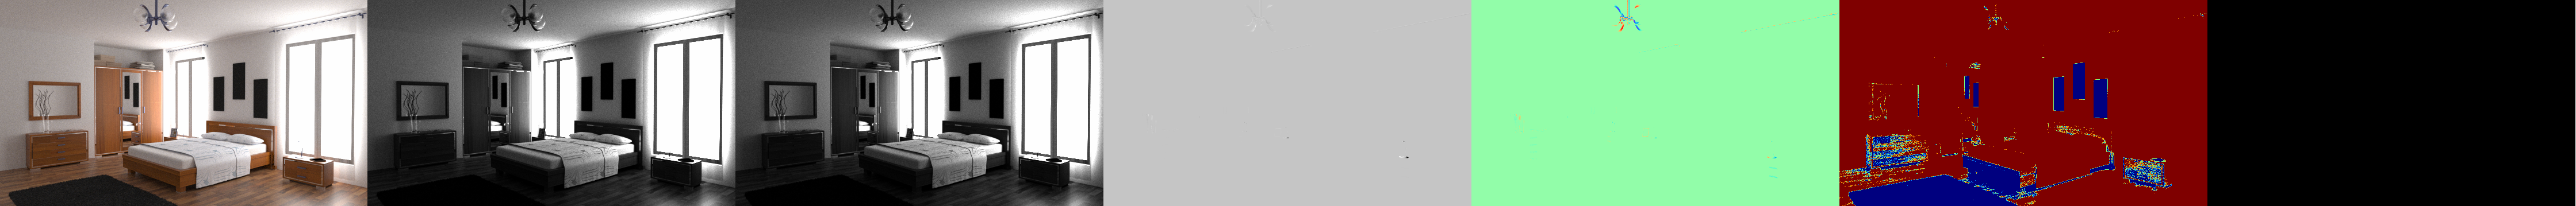

In [85]:
rgb(
    panelize(
        rgb(sample["rgb"], as_tensor=True),
        rgb(sample["S0"].clamp(0,1), as_tensor=True,colormap="gray"),
        rgb(sample["S1"].clamp(0,1), as_tensor=True,colormap="gray"),
        rgb(sample["S2"], as_tensor=True,colormap="gray"),
        rgb(sample["AoP"], as_tensor=True,colormap="rainbow"),
        rgb(sample["DoP"], as_tensor=True,colormap="jet"),
        rgb(1/sample["f_spec"], as_tensor=True,colormap="gray"),
    )
)

In [ ]:
import numpy as np

s0 = torch.from_numpy(
    np.load(
        "/anvme/workspace/v120bb18-unreflectanything/datasets/SyntheticMitsuba/scene_0/pol/000000_S0.npy"
    ).astype(np.float32)
)
s1 = torch.from_numpy(
    np.load(
        "/anvme/workspace/v120bb18-unreflectanything/datasets/SyntheticMitsuba/scene_0/pol/000000_S1.npy"
    ).astype(np.float32)
)
s2 = torch.from_numpy(
    np.load(
        "/anvme/workspace/v120bb18-unreflectanything/datasets/SyntheticMitsuba/scene_0/pol/000000_S2.npy"
    ).astype(np.float32)
)

In [ ]:
s0[:, :, 0]

tensor([[0.2801, 0.2978, 0.2841,  ..., 0.5105, 0.5212, 0.5625],
        [0.2862, 0.3037, 0.3052,  ..., 0.5598, 0.6175, 0.6582],
        [0.3038, 0.2721, 0.3020,  ..., 0.6140, 0.6165, 0.6919],
        ...,
        [0.0928, 0.0921, 0.0898,  ..., 0.2410, 0.2235, 0.2164],
        [0.0957, 0.0978, 0.0884,  ..., 0.2658, 0.2622, 0.3105],
        [0.0831, 0.0816, 0.1217,  ..., 0.2907, 0.3059, 0.2743]])

In [ ]:
s0[:, :, 1]

tensor([[0.2523, 0.2603, 0.2502,  ..., 0.4698, 0.4877, 0.5225],
        [0.2450, 0.2565, 0.2709,  ..., 0.5363, 0.5789, 0.6198],
        [0.2714, 0.2364, 0.2678,  ..., 0.5651, 0.5686, 0.6331],
        ...,
        [0.0544, 0.0606, 0.0563,  ..., 0.1497, 0.1370, 0.1347],
        [0.0646, 0.0627, 0.0542,  ..., 0.1600, 0.1512, 0.1766],
        [0.0546, 0.0500, 0.0758,  ..., 0.1725, 0.1738, 0.1583]])

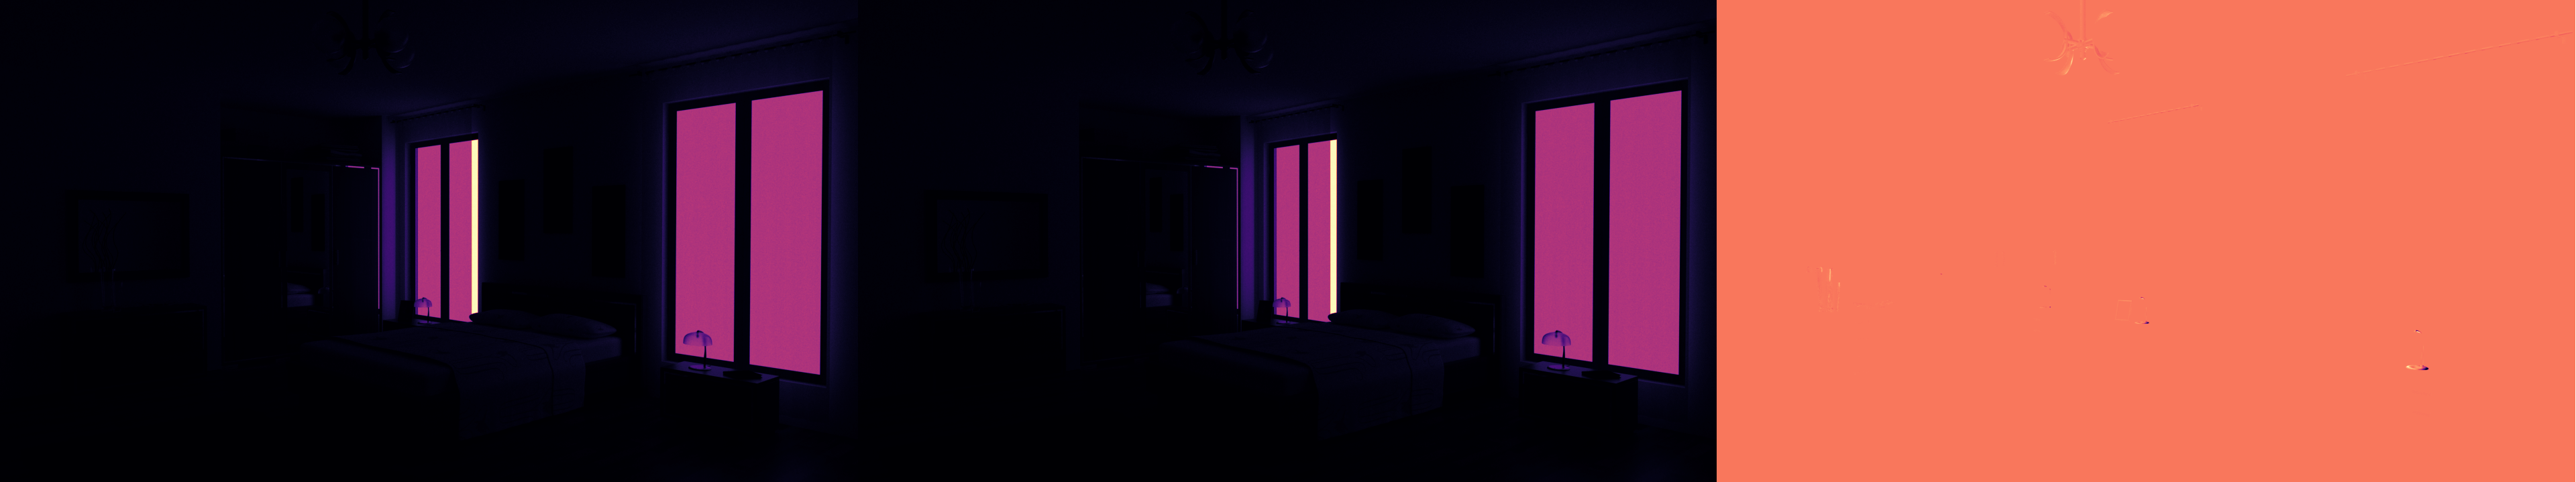

In [ ]:
rgb(
    panelize(
        rgb(s0m, as_tensor=True), rgb(s1m, as_tensor=True), rgb(s2m, as_tensor=True)
    )
)

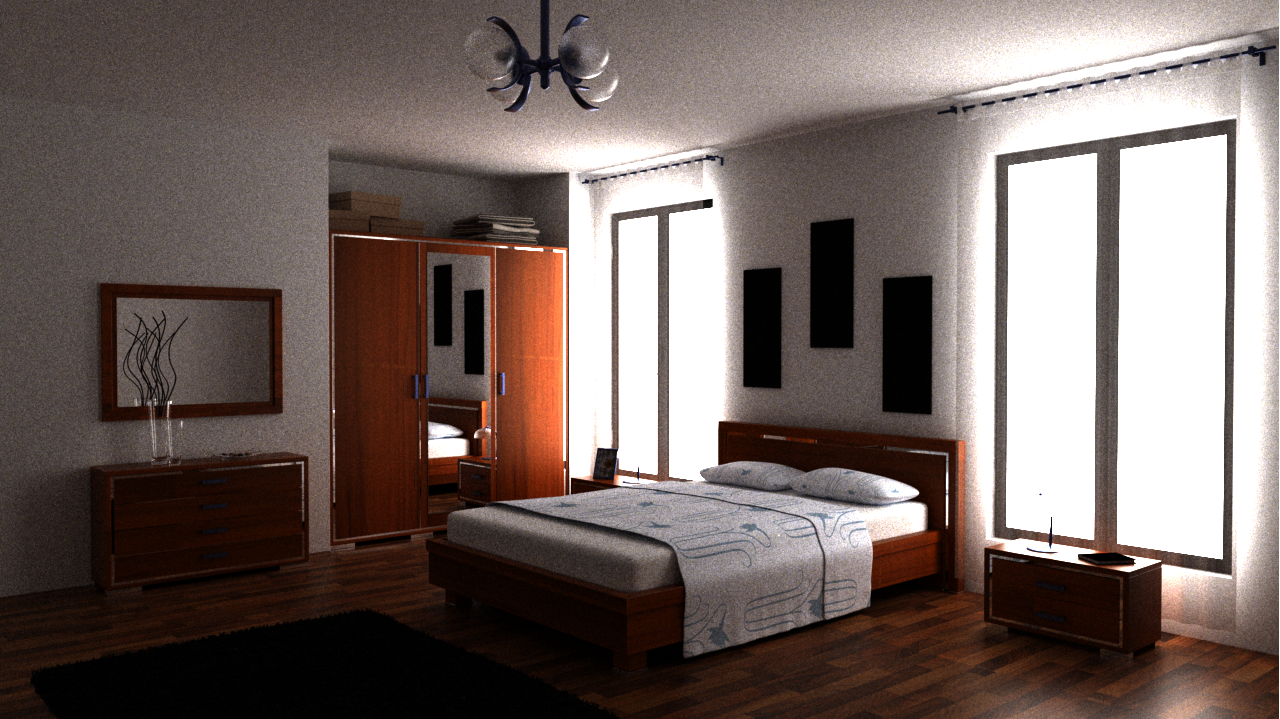

In [ ]:
rgb(s0.clamp(0, 1))

In [ ]:
s0[:, :, 0] - s0[:, :, 1]

tensor([[0.0278, 0.0375, 0.0339,  ..., 0.0407, 0.0335, 0.0400],
        [0.0411, 0.0473, 0.0343,  ..., 0.0236, 0.0386, 0.0385],
        [0.0324, 0.0357, 0.0342,  ..., 0.0489, 0.0479, 0.0588],
        ...,
        [0.0384, 0.0314, 0.0335,  ..., 0.0913, 0.0866, 0.0817],
        [0.0311, 0.0351, 0.0341,  ..., 0.1058, 0.1110, 0.1339],
        [0.0285, 0.0316, 0.0459,  ..., 0.1182, 0.1321, 0.1161]])

In [ ]:
from tqdm.notebook import tqdm

threshhold = 0
good_idxs = []


percentage = sample["rect_mask"][0].sum() / sample["rect_crop"][0].numel() * 100
# print(
#     f"Percentage of highlighted pixels in output: {percentage}%"
# )
rgb(
    panelize(
        rgb(
            sample["rgb"][0],
            # resize=(512,640),
            as_tensor=True,
        ),
        rgb(
            sample["highlight_masks"][0],
            # resize=(640,640),
            as_tensor=True,
        ),
        rgb(
            draw_rect(sample["rgb"][0], (255, 0, 0), 4, sample["rect_coords"][0]),
            # resize=(512,640),
            as_tensor=True,
        ),
        rgb(sample["rect_crop"][0], resize=(640, 640), as_tensor=True),
        rgb(
            sample["rect_mask"][0],
            resize=(640, 640),
            as_tensor=True,
            colormap="gray",
        ),
        resize_to_match=False,
    )
)

In [7]:
sample["rgb"].max()

tensor(1.)

In [40]:
import torch
from transformers import AutoImageProcessor, AutoModel
from transformers.image_utils import load_image

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = load_image(url)

pretrained_model_name = "facebook/dinov3-vitb16-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(pretrained_model_name)
model = AutoModel.from_pretrained(pretrained_model_name).cuda()
model.config.image_size = (448, 448)
inputs = processor(images=image, return_tensors="pt").to(model.device)
inputs["pixel_values"] = sample["framestack"][:1, 0].cuda()
with torch.inference_mode():
    outputs = model(**inputs)

pooled_output = outputs.pooler_output
lhs = outputs.last_hidden_state
print("Pooled output shape:", pooled_output.shape)
print("Last hidden state shape:", lhs.shape)

Pooled output shape:
torch.Size([1, 768])

Last hidden state shape:
torch.Size([1, 789, 768])

In [25]:
embedding2chw(lhs[:, 1:]).shape

torch.Size([1, 768, 20, 29])

In [19]:
lhs.shape

torch.Size([1, 581, 768])

In [9]:
224 / 16 * 14

196.0

In [ ]:
import rerun as rr
import rerun.blueprint as rrb

rr.init("Point Reflection Generator")
rr.serve_web(web_port=0, grpc_port=torch.randint(10000, 65535, (1,)).item())
rr.send_blueprint(
    rrb.Blueprint(
        rrb.Vertical(
            rrb.Horizontal(
                rrb.Spatial2DView(origin="/source", name="Source RGB"),
                rrb.Spatial3DView(origin="/3d", name="3D Cloud"),
            ),
            rrb.Horizontal(
                rrb.Spatial2DView(origin="/sourceref", name="Source and Reflections"),
                rrb.Spatial2DView(origin="/ref", name="Reflections Mask"),
            ),
            6,
        )
    )
)
rr.log("/3d", rr.ViewCoordinates.RIGHT_HAND_Y_DOWN)
rr.set_time("frame", sequence=0)

In [5]:
import yaml
from dotmap import DotMap

import projections
from pipelines.depth.depth import DepthPipeline

### Load Sample
# sample = next(iloader)
### Load Configuration
# We load the configuration from the YAML file and convert it to a DotMap for easy access.
CONFIG_PATH = "../config.yaml"
with open(CONFIG_PATH, "r") as f:
    config_yaml = yaml.safe_load(f)
    config_parameters = config_yaml["parameters"]
    config_training_dict = {
        k: v.get("value") for k, v in config_parameters.items() if v is not None
    }
    config = DotMap(config_training_dict)
config.IMAGE_HEIGHT = 384
config.IMAGE_WIDTH = 384

highlighter = projections.HighLightRenderer(
    config.IMAGE_HEIGHT, config.IMAGE_WIDTH
).cuda()
backproject = projections.BackProject(config.IMAGE_HEIGHT, config.IMAGE_WIDTH).cuda()
config.DEPTH_SCALE_FACTOR = 20
config.DEPTH_BIAS_FACTOR = 60

depthPipeline = DepthPipeline(config, model="", device="cuda")
cropdepth = depthPipeline.depth(sample["rect_crop"][:, 0].cuda())
K = sample["intrinsics"][0].cuda()

### Parameters
LIGHT_INTENSITY = 100.0
LIGHT_COLOR = torch.tensor([1.0, 1.0, 1.0]).cuda()
SURFACE_SHININESS = 0.8
REFLECTION_STRENGTH = 0.5

light_position_start = 10 * torch.randn(3).cuda()
light_position_end = 10 * torch.randn(3).cuda()

### Parameters
for light_sample in range(50):
    rr.set_time("frame", sequence=light_sample)
    POINT_LIGHT_POSITION = (
        light_position_start
        + (light_position_end - light_position_start) * light_sample / 50
    )
    xyz1, _, rgbvec = backproject(
        sample["rect_crop"][:, 0].cuda(),
        cropdepth,
        torch.inverse(K).unsqueeze(0),
    ).values()
    refres = highlighter.forward_point_light(
        cloud=xyz1,
        rgb_vec=rgbvec,
        camera_K=K.unsqueeze(0),
        camera_T=torch.eye(4).unsqueeze(0).cuda(),
        light_position=POINT_LIGHT_POSITION,
        light_intensity=LIGHT_INTENSITY,
        light_color=LIGHT_COLOR,
        surface_roughness=SURFACE_SHININESS,
        reflection_strength=REFLECTION_STRENGTH,
    )

    rr.log(
        "/3d/cloud",
        rr.Points3D(
            positions=xyz1[0, :3].permute(1, 0).cpu().numpy(),
            colors=rgbvec[0].permute(1, 0).cpu().numpy(),
        ),
        static=True,
    )
    rr.log(
        "/3d/cam",
        rr.Pinhole(
            image_from_camera=K.cpu(),  # (3, 3)
            resolution=(384, 384),  # (2,)
            camera_xyz=rr.components.ViewCoordinates.RDF,  # Default: X=Right, Y=Down, Z=Forward
        ),
        static=True,
    )

    all_reflections = refres["reflection_only"][0].mean(0, keepdim=True)
    all_reflections[sample["rect_mask"][0, 0] == 1] = 1.5
    rr.log(
        "/ref",
        rr.Image(
            rgb(all_reflections, as_tensor=True, colormap="jet")
            .permute(2, 1, 0)
            .cpu()
            .numpy()
        ),
    )
    rr.log(
        "/source",
        rr.Image(
            rgb(
                sample["rect_crop"][0, 0],
                resize=(config.IMAGE_HEIGHT, config.IMAGE_WIDTH),
                as_tensor=True,
            )
            .permute(2, 1, 0)
            .cpu()
            .numpy()
        ),
    )
    rr.log(
        "/sourceref",
        rr.Image(
            rgb(refres["warped"][0], as_tensor=True).permute(2, 1, 0).cpu().numpy()
        ),
    )
    rr.log(
        "/3d/light",
        rr.Points3D(
            positions=POINT_LIGHT_POSITION.cpu().numpy(),
            colors=LIGHT_COLOR.cpu().numpy(),
            radii=2,
        ),
    )
    # rgb(
    #     panelize(
    #         rgb(sample["rect_crop"][0,0],resize=(config.IMAGE_HEIGHT,config.IMAGE_WIDTH),as_tensor=True),
    #         rgb(refres["warped"][0],resize=(config.IMAGE_HEIGHT,config.IMAGE_WIDTH),as_tensor=True),
    #         rgb(refres["reflection_only"][0],resize=(config.IMAGE_HEIGHT,config.IMAGE_WIDTH),as_tensor=True,colormap="gray"),
    #     )
    # )

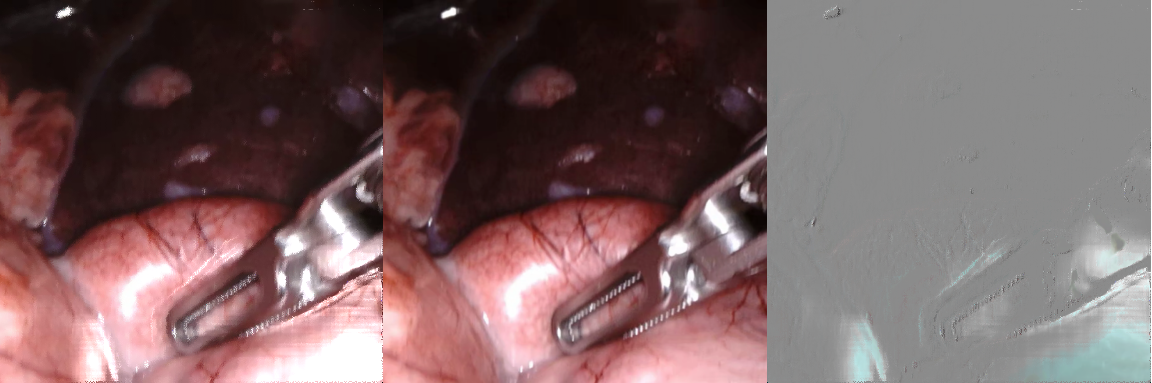

In [6]:
both = refres["warped"][0].cpu()
orig = sample["rect_crop"][:, 0].cpu()
diff = both - orig
rgb(
    panelize(
        rgb(both, as_tensor=True), rgb(orig, as_tensor=True), rgb(diff, as_tensor=True)
    )
)

In [7]:
import rerun as rr
import rerun.blueprint as rrb

rr.init("Planar Reflection Generator")
rr.serve_web(web_port=0, grpc_port=torch.randint(10000, 65535, (1,)).item())
rr.send_blueprint(
    rrb.Blueprint(
        rrb.Vertical(
            rrb.Horizontal(
                rrb.Spatial2DView(origin="/source", name="Source RGB"),
                rrb.Spatial3DView(origin="/3d", name="3D Cloud"),
            ),
            rrb.Horizontal(
                rrb.Spatial2DView(origin="/sourceref", name="Source and Reflections"),
                rrb.Spatial2DView(origin="/ref", name="Reflections Mask"),
            ),
        )
    )
)
rr.log("/3d", rr.ViewCoordinates.RIGHT_HAND_Y_DOWN)
rr.set_time("frame", sequence=0)

In [8]:
import torch
import yaml
from dotmap import DotMap

import projections
from pipelines.depth.depth import DepthPipeline

### Load Sample
# sample = next(iloader)

### Load Configuration
CONFIG_PATH = "../config.yaml"
with open(CONFIG_PATH, "r") as f:
    config_yaml = yaml.safe_load(f)
    config_parameters = config_yaml["parameters"]
    config_training_dict = {
        k: v.get("value") for k, v in config_parameters.items() if v is not None
    }
    config = DotMap(config_training_dict)
config.IMAGE_HEIGHT = 384
config.IMAGE_WIDTH = 384

highlighter = projections.HighLightRenderer(
    config.IMAGE_HEIGHT, config.IMAGE_WIDTH
).cuda()
backproject = projections.BackProject(config.IMAGE_HEIGHT, config.IMAGE_WIDTH).cuda()
config.DEPTH_SCALE_FACTOR = 20
config.DEPTH_BIAS_FACTOR = 60

depthPipeline = DepthPipeline(config, model="", device="cuda")
cropdepth = depthPipeline.depth(sample["rect_crop"][:, 0].cuda())
K = sample["intrinsics"][0].cuda()

light_position = 10 * torch.randn(3).cuda() - 10
light_eulangs = 5 * torch.randn(3).cuda()
light_eulangs[-1] = torch.abs(light_eulangs[-1])
LIGHT_POSE = torch.cat([light_position, light_eulangs], dim=0)
LIGHT_POSE_START = LIGHT_POSE.unsqueeze(0)

light_position = 5 * torch.randn(3).cuda() - 10
light_eulangs = 0.1 * torch.randn(3).cuda()
light_eulangs[-1] = torch.abs(light_eulangs[-1])
LIGHT_POSE = torch.cat([light_position, light_eulangs], dim=0)
LIGHT_POSE_END = LIGHT_POSE.unsqueeze(0)

LIGHT_WIDTH = 100  # Width of rectangular light (in meters)
LIGHT_HEIGHT = 80  # Height of rectangular light (in meters)
LIGHT_SAMPLES = 10 * 8
for light_sample in range(50):
    rr.set_time("frame", sequence=light_sample)
    LIGHT_POSE_EUL = (
        LIGHT_POSE_START + (LIGHT_POSE_END - LIGHT_POSE_START) * light_sample / 50
    )
    ### Planar Light Parameters
    LIGHT_INTENSITY = 10.0 / LIGHT_SAMPLES
    LIGHT_COLOR = torch.tensor([1.0, 1.0, 1.0]).cuda()
    SURFACE_SHININESS = 0.8
    REFLECTION_STRENGTH = 0.1

    # Create planar light pose matrix
    # Position the light at a random location similar to your point light
    LIGHT_POSE = e2m(LIGHT_POSE_EUL)

    ### Backproject and render with planar light
    xyz1, _, rgbvec = backproject(
        sample["rect_crop"][:, 0].cuda(),
        cropdepth,
        torch.inverse(K).unsqueeze(0),
    ).values()

    refres = highlighter.forward_planar_light(
        cloud=xyz1,
        rgb_vec=rgbvec,
        camera_K=K.unsqueeze(0),
        camera_T=torch.eye(4).unsqueeze(0).cuda(),
        light_pose=LIGHT_POSE,
        light_width=LIGHT_WIDTH,
        light_height=LIGHT_HEIGHT,
        light_samples=LIGHT_SAMPLES,
        light_intensity=LIGHT_INTENSITY,
        light_color=LIGHT_COLOR,
        surface_roughness=SURFACE_SHININESS,
        reflection_strength=REFLECTION_STRENGTH,
    )

    ### Visualization
    # Log the point cloud
    rr.log(
        "/3d/cloud",
        rr.Points3D(
            positions=xyz1[0, :3].permute(1, 0).cpu().numpy(),
            colors=rgbvec[0].permute(1, 0).cpu().numpy(),
        ),
        static=True,
    )

    # Log camera
    rr.log(
        "/3d/cam",
        rr.Pinhole(
            image_from_camera=K.cpu(),
            resolution=(384, 384),
            camera_xyz=rr.components.ViewCoordinates.RDF,
        ),
        static=True,
    )

    ### Create and log rectangular light plane visualization

    def create_rectangular_light_mesh(LIGHT_POSE, width, height):
        """
        Create mesh vertices and triangles for a rectangular light plane.

        Args:
            LIGHT_POSE: [1, 4, 4] pose matrix
            width: light width
            height: light height

        Returns:
            vertices: [4, 3] corner positions in world coordinates
            triangles: [2, 3] triangle indices for the rectangle
        """
        # Create rectangle corners in light's local coordinate system
        half_w, half_h = width / 2, height / 2
        local_corners = torch.tensor(
            [
                [-half_w, -half_h, 0],  # Bottom-left
                [half_w, -half_h, 0],  # Bottom-right
                [half_w, half_h, 0],  # Top-right
                [-half_w, half_h, 0],  # Top-left
            ],
            dtype=torch.float32,
            device=LIGHT_POSE.device,
        )  # [4, 3]

        # Convert to homogeneous coordinates
        local_corners_homo = torch.cat(
            [local_corners, torch.ones(4, 1, device=LIGHT_POSE.device)], dim=1
        )  # [4, 4]

        # Transform to world coordinates
        # LIGHT_POSE is world-to-light, so we need light-to-world (inverse)
        light_to_world = torch.linalg.inv(LIGHT_POSE[0])  # [4, 4]
        world_corners = (light_to_world @ local_corners_homo.T).T  # [4, 4]

        # Extract 3D coordinates
        vertices = world_corners[:, :3]  # [4, 3]

        # Define triangles (two triangles make a rectangle)
        triangles = torch.tensor(
            [
                [0, 1, 2],  # First triangle
                [0, 2, 3],  # Second triangle
            ],
            dtype=torch.int32,
        )

        return vertices, triangles

    # Create rectangular light mesh
    vertices, triangles = create_rectangular_light_mesh(
        LIGHT_POSE, LIGHT_WIDTH, LIGHT_HEIGHT
    )

    # Log the rectangular light as a mesh
    rr.log(
        "/3d/light_plane",
        rr.Mesh3D(
            vertex_positions=vertices.cpu().numpy(),
            triangle_indices=triangles.cpu().numpy(),
            vertex_colors=np.tile(
                LIGHT_COLOR.cpu().numpy(), (4, 1)
            ),  # Same color for all vertices
        ),
    )

    # Optional: Log light plane outline for better visibility
    light_outline = torch.cat([vertices, vertices[0:1]], dim=0)  # Close the loop
    rr.log(
        "/3d/light_outline",
        rr.LineStrips3D(
            strips=[light_outline.cpu().numpy()],
            colors=[LIGHT_COLOR.cpu().numpy()],
            radii=0.05,
        ),
    )

    # Optional: Log light center point
    light_center = LIGHT_POSE[0, :3, 3]  # [3]
    rr.log(
        "/3d/light_center",
        rr.Points3D(
            positions=light_center.cpu().numpy().reshape(1, 3),
            colors=LIGHT_COLOR.cpu().numpy().reshape(1, 3),
            radii=0.1,
        ),
    )

    # Log images (same as before)
    all_reflections = refres["reflection_only"][0].mean(0, keepdim=True)
    all_reflections[sample["rect_mask"][0, 0] == 1] = 1.5

    rr.log(
        "/ref",
        rr.Image(
            rgb(all_reflections, as_tensor=True, colormap="jet")
            .permute(2, 1, 0)
            .cpu()
            .numpy()
        ),
    )

    rr.log(
        "/source",
        rr.Image(
            rgb(
                sample["rect_crop"][0, 0],
                resize=(config.IMAGE_HEIGHT, config.IMAGE_WIDTH),
                as_tensor=True,
            )
            .permute(2, 1, 0)
            .cpu()
            .numpy()
        ),
    )

    rr.log(
        "/sourceref",
        rr.Image(
            rgb(refres["warped"][0], as_tensor=True).permute(2, 1, 0).cpu().numpy()
        ),
    )

In [27]:
import rerun as rr
import rerun.blueprint as rrb

rr.init("Image Reflection Generator")
rr.serve_web(web_port=0, grpc_port=torch.randint(10000, 65535, (1,)).item())
rr.send_blueprint(
    rrb.Blueprint(
        rrb.Vertical(
            rrb.Horizontal(
                rrb.Spatial2DView(origin="/source", name="Source RGB"),
                rrb.Spatial3DView(origin="/3d", name="3D Cloud"),
            ),
            rrb.Horizontal(
                rrb.Spatial2DView(origin="/sourceref", name="Source and Reflections"),
                rrb.Spatial2DView(origin="/ref", name="Reflections Mask"),
            ),
        )
    )
)
rr.set_time("frame", sequence=0)
rr.log("/3d", rr.ViewCoordinates.RIGHT_HAND_Y_DOWN)

In [29]:
from typing import Any, Union

import numpy as np
import torch
import yaml
from dotmap import DotMap
from scipy.spatial.transform import Rotation

import projections
from pipelines.depth.depth import DepthPipeline


def log_rerun_camera(
    K: Union[
        torch.Tensor, np.ndarray
    ],  # (3, 3) camera intrinsics matrix, torch.Tensor or np.ndarray
    pose: Union[
        torch.Tensor, np.ndarray
    ],  # (4, 4) camera-to-world pose, torch.Tensor or np.ndarray
    height: int = 384,  # int, image height
    width: int = 384,  # int, image width
    entity: str = "/camera",  # str, rerun entity path
    **kwargs: Any,
) -> None:
    """
    Logs a camera as a Rerun Pinhole object at a specific pose.

    Args:
        K: (3, 3) camera intrinsics matrix (fx, 0, cx; 0, fy, cy; 0, 0, 1)
        height: int, image height
        width: int, image width
        pose: (4, 4) camera-to-world pose matrix
        entity: str, rerun entity path
    """
    # Convert to numpy if torch
    if isinstance(K, torch.Tensor):
        K = K.detach().cpu().numpy()
    if isinstance(pose, torch.Tensor):
        pose = pose.detach().cpu().numpy()

    R = pose[:3, :3]
    t = pose[:3, 3]

    rot = Rotation.from_matrix(R)
    axis_angle = rot.as_rotvec()
    axis = axis_angle / (np.linalg.norm(axis_angle) + 1e-10)  # Normalize axis
    angle = np.linalg.norm(axis_angle)  # Extract angle

    rr.log(
        entity,
        rr.Transform3D(
            translation=t,
            rotation_axis_angle=rr.RotationAxisAngle(axis=axis, radians=angle),
            axis_length=0.1,
        ),
    )

    # Log the pinhole camera
    rr.log(
        entity,
        rr.Pinhole(
            image_from_camera=K,  # (3, 3)
            resolution=(width, height),  # (2,)
            camera_xyz=rr.components.ViewCoordinates.RDF,  # Default: X=Right, Y=Down, Z=Forward
            **kwargs,
        ),
    )


### Load Sample
# sample = next(iloader)

### Load Configuration
CONFIG_PATH = "../config.yaml"
with open(CONFIG_PATH, "r") as f:
    config_yaml = yaml.safe_load(f)
    config_parameters = config_yaml["parameters"]
    config_training_dict = {
        k: v.get("value") for k, v in config_parameters.items() if v is not None
    }
    config = DotMap(config_training_dict)
config.IMAGE_HEIGHT = 384
config.IMAGE_WIDTH = 384

highlighter = projections.HighLightRenderer(
    config.IMAGE_HEIGHT, config.IMAGE_WIDTH
).cuda()
backproject = projections.BackProject(config.IMAGE_HEIGHT, config.IMAGE_WIDTH).cuda()
config.DEPTH_SCALE_FACTOR = 20
config.DEPTH_BIAS_FACTOR = 60

depthPipeline = DepthPipeline(config, model="", device="cuda")
cropdepth = depthPipeline.depth(sample["rect_crop"][:, 0].cuda())
K = sample["intrinsics"][0].cuda()

light_position = 10 * torch.randn(3).cuda() - 10
light_eulangs = 5 * torch.randn(3).cuda()
light_eulangs[-1] = torch.abs(light_eulangs[-1])
LIGHT_POSE = torch.cat([light_position, light_eulangs], dim=0)
LIGHT_POSE_START = LIGHT_POSE.unsqueeze(0)

light_position = 5 * torch.randn(3).cuda() - 10
light_eulangs = 0.01 * torch.randn(3).cuda()
light_eulangs[0] = torch.abs(light_eulangs[0])
LIGHT_POSE = torch.cat([light_position, light_eulangs], dim=0)
LIGHT_POSE_END = LIGHT_POSE.unsqueeze(0)

LIGHT_WIDTH = 5 * 15  # Width of rectangular light (in meters)
LIGHT_HEIGHT = 4 * 15  # Height of rectangular light (in meters)
LIGHT_SAMPLES = 200


IMAGE_TO_PROJECT = Image.open("../assets/uiiai.png")
IMAGE_TO_PROJECT = np.array(IMAGE_TO_PROJECT) / 255
IMAGE_TO_PROJECT = (
    torch.from_numpy(IMAGE_TO_PROJECT).permute(2, 0, 1).unsqueeze(0).float().cuda()
)

IMAGE_TO_PROJECT = sample["rect_crop"][0, 0].unsqueeze(0).cuda()
for light_sample in range(50):
    rr.set_time("frame", sequence=light_sample)
    LIGHT_POSE_EUL = (
        LIGHT_POSE_START + (LIGHT_POSE_END - LIGHT_POSE_START) * light_sample / 50
    )
    ### Planar Light Parameters
    LIGHT_INTENSITY = 10.0 / LIGHT_SAMPLES
    LIGHT_COLOR = torch.tensor([1.0, 1.0, 1.0]).cuda()
    SURFACE_SHININESS = 0.5
    REFLECTION_STRENGTH = 0.2
    # Create planar light pose matrix
    # Position the light at a random location similar to your point light
    LIGHT_POSE = e2m(LIGHT_POSE_EUL)

    ### Backproject and render with planar light
    xyz1, _, rgbvec = backproject(
        sample["rect_crop"][:, 0].cuda(),
        cropdepth,
        torch.inverse(K).unsqueeze(0),
    ).values()

    refres = highlighter.forward_planar_light(
        cloud=xyz1,
        rgb_vec=rgbvec,
        camera_K=K.unsqueeze(0),
        camera_T=torch.eye(4).unsqueeze(0).cuda(),
        light_pose=LIGHT_POSE,
        light_width=LIGHT_WIDTH,
        light_height=LIGHT_HEIGHT,
        light_samples=LIGHT_SAMPLES,
        light_intensity=LIGHT_INTENSITY,
        light_color=LIGHT_COLOR,  # Used as fallback, but projected_image takes precedence
        projected_image=IMAGE_TO_PROJECT,  # NEW: RGB image to project!
        surface_roughness=SURFACE_SHININESS,
        reflection_strength=REFLECTION_STRENGTH,
    )

    ### Visualization
    rr.log(
        "/3d/cloud",
        rr.Points3D(
            positions=xyz1[0, :3].permute(1, 0).cpu().numpy(),
            colors=rgbvec[0].permute(1, 0).cpu().numpy(),
        ),
        static=True,
    )

    # Log camera
    rr.log(
        "/3d/cam",
        rr.Pinhole(
            image_from_camera=K.cpu(),
            resolution=(384, 384),
            camera_xyz=rr.components.ViewCoordinates.RDF,
        ),
        static=True,
    )

    ### Create and log light projector transform and pinhole

    # Create pinhole for the light projector
    light_to_world = torch.linalg.inv(LIGHT_POSE[0])  # [4, 4]

    # Create a simple projection matrix for the light
    # Using a basic pinhole model with focal length based on light dimensions
    focal_length = max(LIGHT_WIDTH, LIGHT_HEIGHT)  # Simple focal length
    light_K = torch.eye(3, device=LIGHT_POSE.device)
    light_K[0, 0] = light_K[1, 1] = focal_length
    light_K[0, 2] = IMAGE_TO_PROJECT[0].shape[1] // 8  # Principal point x
    light_K[1, 2] = IMAGE_TO_PROJECT[0].shape[2] // 8  # Principal point y

    # Log the projected image for reference
    log_rerun_camera(
        light_K,
        LIGHT_POSE[0],
        height=IMAGE_TO_PROJECT[0].shape[1] / 4,
        width=IMAGE_TO_PROJECT[0].shape[2] / 4,
        entity="/3d/light",
    )
    rr.log(
        "/3d/light/projected_image",
        rr.Image(
            rgb(
                IMAGE_TO_PROJECT[0],
                resize=(
                    IMAGE_TO_PROJECT[0].shape[1] // 4,
                    IMAGE_TO_PROJECT[0].shape[2] // 4,
                ),
                as_tensor=True,
            )
            .permute(2, 1, 0)
            .cpu()
            .numpy()
        ),
    )

    # Log images showing the projection effect
    all_reflections = refres["reflection_only"][0].mean(0, keepdim=True)
    all_reflections[sample["rect_mask"][0, 0] == 1] = 1.5

    rr.log(
        "/ref",
        rr.Image(
            rgb(all_reflections, as_tensor=True, colormap="jet")
            .permute(2, 1, 0)
            .cpu()
            .numpy()
        ),
    )

    rr.log(
        "/source",
        rr.Image(
            rgb(
                sample["rect_crop"][0, 0],
                resize=(config.IMAGE_HEIGHT, config.IMAGE_WIDTH),
                as_tensor=True,
            )
            .permute(2, 1, 0)
            .cpu()
            .numpy()
        ),
    )

    rr.log(
        "/sourceref",
        rr.Image(
            rgb(refres["warped"][0], as_tensor=True).permute(2, 1, 0).cpu().numpy()
        ),
    )

In [25]:
IMAGE_TO_PROJECT.shape

torch.Size([3, 384, 384])

In [10]:
from typing import Any, Union


def log_rerun_camera(
    K: Union[
        torch.Tensor, np.ndarray
    ],  # (3, 3) camera intrinsics matrix, torch.Tensor or np.ndarray
    pose: Union[
        torch.Tensor, np.ndarray
    ],  # (4, 4) camera-to-world pose, torch.Tensor or np.ndarray
    height: int = 384,  # int, image height
    width: int = 384,  # int, image width
    entity: str = "/camera",  # str, rerun entity path
    **kwargs: Any,
) -> None:
    """
    Logs a camera as a Rerun Pinhole object at a specific pose.

    Args:
        K: (3, 3) camera intrinsics matrix (fx, 0, cx; 0, fy, cy; 0, 0, 1)
        height: int, image height
        width: int, image width
        pose: (4, 4) camera-to-world pose matrix
        entity: str, rerun entity path
    """
    # Convert to numpy if torch
    if isinstance(K, torch.Tensor):
        K = K.detach().cpu().numpy()
    if isinstance(pose, torch.Tensor):
        pose = pose.detach().cpu().numpy()

    R = pose[:3, :3]
    t = pose[:3, 3]

    rot = Rotation.from_matrix(R)
    axis_angle = rot.as_rotvec()
    axis = axis_angle / (np.linalg.norm(axis_angle) + 1e-10)  # Normalize axis
    angle = np.linalg.norm(axis_angle)  # Extract angle

    rr.log(
        entity,
        rr.Transform3D(
            translation=t,
            rotation_axis_angle=rr.RotationAxisAngle(axis=axis, radians=angle),
            axis_length=0.1,
        ),
    )

    # Log the pinhole camera
    rr.log(
        entity,
        rr.Pinhole(
            image_from_camera=K,  # (3, 3)
            resolution=(width, height),  # (2,)
            camera_xyz=rr.components.ViewCoordinates.RDF,  # Default: X=Right, Y=Down, Z=Forward
            **kwargs,
        ),
    )